# Step10 — run and review notebook

This notebook is the **execution + QC + review** notebook for Step10.

It follows the same pattern as the Step09 notebook:

1. configure paths and options  
2. run the production scripts  
3. inspect the intermediate products  
4. inspect the final corrected spectra  
5. hand off cleanly to the next step

## Step10 logic

- **10a**: build empirical telluric O2 templates
  - `O2_BAND`
  - `O2_ABAND`
- **10b**: apply empirical telluric correction slit by slit
  - separate fit for B band and A band
  - separate shift and amplitude per band
  - output corrected flux and variance columns

## Important note

The uploaded Step10 scripts still carry some **old default plumbing** from the earlier OH-refine layout.
This notebook therefore calls them with **explicit input and output arguments** rather than relying on their defaults.

In [1]:
from pathlib import Path
import os
import subprocess
import shlex
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
import matplotlib.pyplot as plt
from IPython.display import display

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

## Configuration

Edit only this cell before running the notebook.

In [42]:
# --- repo / environment ---
REPO = Path("/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline")
PYTHON = "python"   # or full path to the environment python if needed

# --- Step09 authoritative input to Step10 ---
INFILE = Path("/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/09_abab/extract1d_optimal_ridge_all_wav_ohclean.fits")

# --- Step10 working directory ---
ROOT10 = Path("/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric
")

# --- one representative slit for focused display ---
SLIT = "SLIT024"

# --- run controls ---
RUN_BUILD_TEMPLATE = True
RUN_APPLY_TELLURIC = True

# --- script locations ---
STEP10A = REPO / "pipeline/step10_telluric/step10a_build_telluric_template.py"
STEP10B = REPO / "pipeline/step10_telluric/step10b_apply_telluric.py"

# --- derived outputs ---
TEMPLATE = ROOT10 / "telluric_O2_template.fits"
OUTFILE  = ROOT10 / "extract1d_optimal_ridge_all_wav_ohclean_tellcorr.fits"

QC_MOSAIC = REPO / "qc/step10/qc_step10_final_mosaic.py"

QC_MOSAIC_DIR = ROOT10 / "qc_step10"  
QC_MOSAIC_PNG = QC_MOSAIC_DIR / "all_stellar_tellcorr_wavelength_montage.png"

RUN_QC_MOSAIC = True

ROOT10.mkdir(parents=True, exist_ok=True)

print("REPO   =", REPO)
print("INFILE =", INFILE, "exists =", INFILE.exists())
print("ROOT10 =", ROOT10, "exists =", ROOT10.exists())
print("SLIT   =", SLIT)

REPO   = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline
INFILE = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/09_abab_official/extract1d_optimal_ridge_all_wav_ohclean.fits exists = True
ROOT10 = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric_official exists = True
SLIT   = SLIT024


In [18]:
def run_cmd(cmd, cwd=REPO, env=None):
    if env is None:
        env = os.environ.copy()
    env["PYTHONPATH"] = "."
    print("[CMD]", " ".join(shlex.quote(str(x)) for x in cmd))
    proc = subprocess.run(
        [str(x) for x in cmd],
        cwd=str(cwd),
        env=env,
        text=True,
        capture_output=True,
    )
    print("--- STDOUT ---")
    print(proc.stdout if proc.stdout.strip() else "[empty]")
    print("--- STDERR ---")
    print(proc.stderr if proc.stderr.strip() else "[empty]")
    if proc.returncode != 0:
        raise RuntimeError(f"Command failed with return code {proc.returncode}")
    return proc

def read_slit_table(fits_path, slit):
    with fits.open(fits_path) as hdul:
        return Table(hdul[slit].data)

def arr(tab, col):
    x = np.asarray(tab[col], float)
    if np.ma.isMaskedArray(x):
        x = x.filled(np.nan)
    return np.ravel(x)

def finite_ylim(*arrays, qlo=0.5, qhi=99.5, pad=0.08):
    vals = []
    for a in arrays:
        a = np.asarray(a, float)
        m = np.isfinite(a)
        if np.any(m):
            vals.append(a[m])
    if not vals:
        return (-1, 1)
    x = np.concatenate(vals)
    lo, hi = np.nanpercentile(x, [qlo, qhi])
    if not np.isfinite(lo) or not np.isfinite(hi) or hi <= lo:
        return (-1, 1)
    d = hi - lo
    return lo - pad * d, hi + pad * d

def pick_flux_tellcorr(tab):
    for c in ["FLUX_TELLCOR_O2", "FLUX"]:
        if c in tab.colnames:
            return c
    return None

def decode_scalar(x):
    return x.decode(errors="ignore").strip() if hasattr(x, "decode") else str(x).strip()

## Inventory before running

In [19]:
for p in [STEP10A, STEP10B, INFILE, ROOT10]:
    print(p, "->", p.exists())

/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step10_telluric/step10a_build_telluric_template.py -> True
/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step10_telluric/step10b_apply_telluric.py -> True
/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/09_abab_official/extract1d_optimal_ridge_all_wav_ohclean.fits -> True
/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric_official -> True


## Execute Step10

Set one or more run flags to `True` in the configuration cell if you want the notebook to actually launch the production scripts.

In [20]:
if RUN_BUILD_TEMPLATE:
    run_cmd([
        PYTHON,
        STEP10A,
        "--infile", INFILE,
        "--outfile", TEMPLATE,
    ])
else:
    print("RUN_BUILD_TEMPLATE = False  -> skipped")

[CMD] python '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step10_telluric/step10a_build_telluric_template.py' --infile '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/09_abab_official/extract1d_optimal_ridge_all_wav_ohclean.fits' --outfile '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric_official/telluric_O2_template.fits'
--- STDOUT ---
INFILE = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/09_abab_official/extract1d_optimal_ridge_all_wav_ohclean.fits
OUTFILE = /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Mas

In [26]:
if RUN_APPLY_TELLURIC:
    run_cmd([
        PYTHON,
        STEP10B,
        "--infile", INFILE,
        "--template", TEMPLATE,
        "--outfile", OUTFILE,
    ])
else:
    print("RUN_APPLY_TELLURIC = False  -> skipped")

[CMD] python '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/pipeline/step10_telluric/step10b_apply_telluric.py' --infile '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/09_abab_official/extract1d_optimal_ridge_all_wav_ohclean.fits' --template '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric_official/telluric_O2_template.fits' --outfile '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric_official/extract1d_optimal_ridge_all_wav_ohclean_tellcorr.fits'
--- STDOUT ---
INFILE  = /Users/robberto/Library/CloudStorage/Box-Box/My Documen

## Inventory after running

In [27]:
for p in [TEMPLATE, OUTFILE]:
    print(p.name, "->", p.exists())

telluric_O2_template.fits -> True
extract1d_optimal_ridge_all_wav_ohclean_tellcorr.fits -> True


## Telluric template inspection

In [28]:
if TEMPLATE.exists():
    with fits.open(TEMPLATE) as h:
        print("Template HDUs:", len(h))
        for ext in h[1:]:
            print(ext.name, h[ext.name].data.names)
else:
    print("Missing:", TEMPLATE)

Template HDUs: 3
O2_BAND ['LAMBDA_NM', 'T_MED', 'TAU_O2']
O2_ABAND ['LAMBDA_NM', 'T_MED', 'TAU_O2']


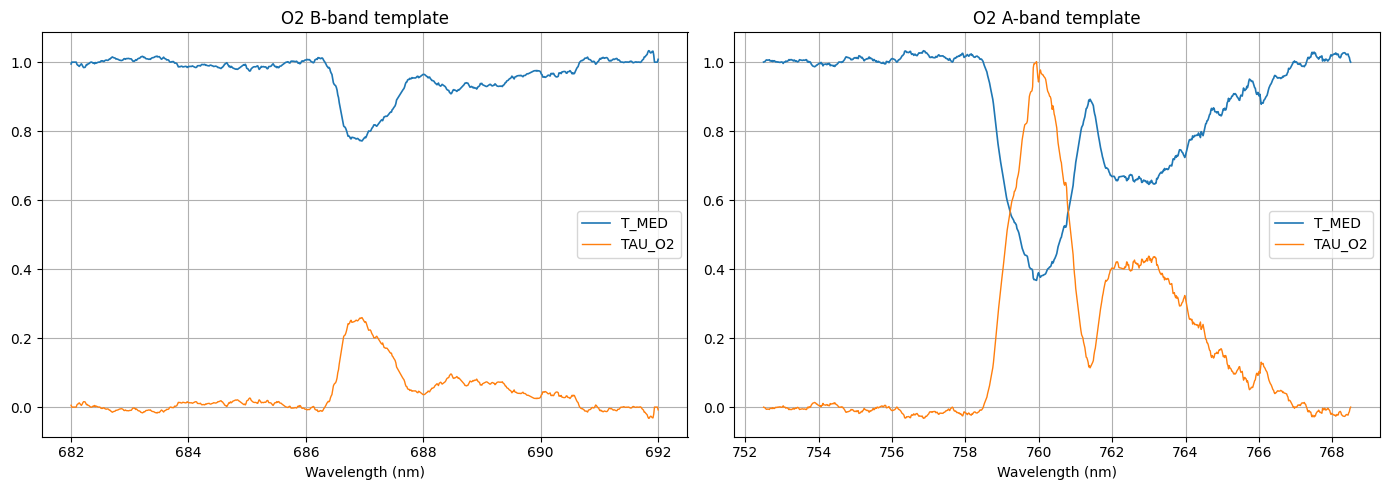

In [29]:
if TEMPLATE.exists():
    with fits.open(TEMPLATE) as h:
        tb = Table(h["O2_BAND"].data)
        ta = Table(h["O2_ABAND"].data)

    lamB = arr(tb, "LAMBDA_NM")
    T_B  = arr(tb, "T_MED")
    tauB = arr(tb, "TAU_O2")

    lamA = arr(ta, "LAMBDA_NM")
    T_A  = arr(ta, "T_MED")
    tauA = arr(ta, "TAU_O2")

    fig = plt.figure(figsize=(14, 5))

    ax = fig.add_subplot(121)
    ax.plot(lamB, T_B, lw=1.2, label="T_MED")
    ax.plot(lamB, tauB, lw=1.0, label="TAU_O2")
    ax.set_title("O2 B-band template")
    ax.set_xlabel("Wavelength (nm)")
    ax.legend()

    ax = fig.add_subplot(122)
    ax.plot(lamA, T_A, lw=1.2, label="T_MED")
    ax.plot(lamA, tauA, lw=1.0, label="TAU_O2")
    ax.set_title("O2 A-band template")
    ax.set_xlabel("Wavelength (nm)")
    ax.legend()

    plt.tight_layout()
    plt.show()

## Final corrected Step10 product

In [30]:
if OUTFILE.exists():
    with fits.open(OUTFILE) as h:
        print("N HDU =", len(h))
        print("First slit =", h[1].name)
        print("Last slit  =", h[-1].name)
        print()
        print("Columns in first slit:")
        print(h[1].data.names)
else:
    print("Missing:", OUTFILE)

N HDU = 63
First slit = SLIT000
Last slit  = SLIT062

Columns in first slit:
['YPIX', 'FLUX', 'VAR', 'SKY', 'OBJ_PRESKY', 'X0', 'NOBJ', 'NSKY', 'SKYSIG', 'APLOSS_FRAC', 'FLUX_APCORR', 'VAR_APCORR', 'EDGEFLAG', 'TRXLEFT', 'TRXRIGHT', 'LAMBDA_NM', 'OH_SHIFT_NM', 'CONTINUUM_P1', 'RESID_P1', 'CONT1', 'RESID1', 'LINE1', 'SIGNAL_CLEAN1', 'CONT2', 'RESID2', 'OH_MODEL_P1', 'STELLAR_P1', 'RESID_POSTOH_P1', 'OH_MODEL', 'STELLAR', 'RESID_POSTOH', 'CONTINUUM_STEP09', 'STEP09_PREF', 'FLUX_TELLCOR_O2', 'VAR_TELLCOR_O2']


In [31]:
if OUTFILE.exists():
    tin = read_slit_table(INFILE, SLIT)
    tout = read_slit_table(OUTFILE, SLIT)

    lam_in = arr(tin, "LAMBDA_NM")
    flux_in_col = "STELLAR" if "STELLAR" in tin.colnames else ("FLUX" if "FLUX" in tin.colnames else None)
    flux_out_col = pick_flux_tellcorr(tout)

    flux_in = arr(tin, flux_in_col) if flux_in_col else None
    flux_out = arr(tout, flux_out_col) if flux_out_col else None

    hdr = fits.getheader(OUTFILE, SLIT)
    keys = ["TELL_OK", "TELL_OKA", "TELL_OKB", "TELL_SHA", "TELL_SHB", "TELL_AA", "TELL_AB", "TELLBAND"]
    for k in keys:
        if k in hdr:
            print(k, "=", hdr[k])
else:
    print("Missing:", OUTFILE)

TELL_OK = True
TELL_OKA = True
TELL_OKB = True
TELL_SHA = 0.8571428571428568
TELL_SHB = 1.6024844720496891
TELL_AA = 0.9185108643218827
TELL_AB = 0.13731726702192545
TELLBAND = A+B


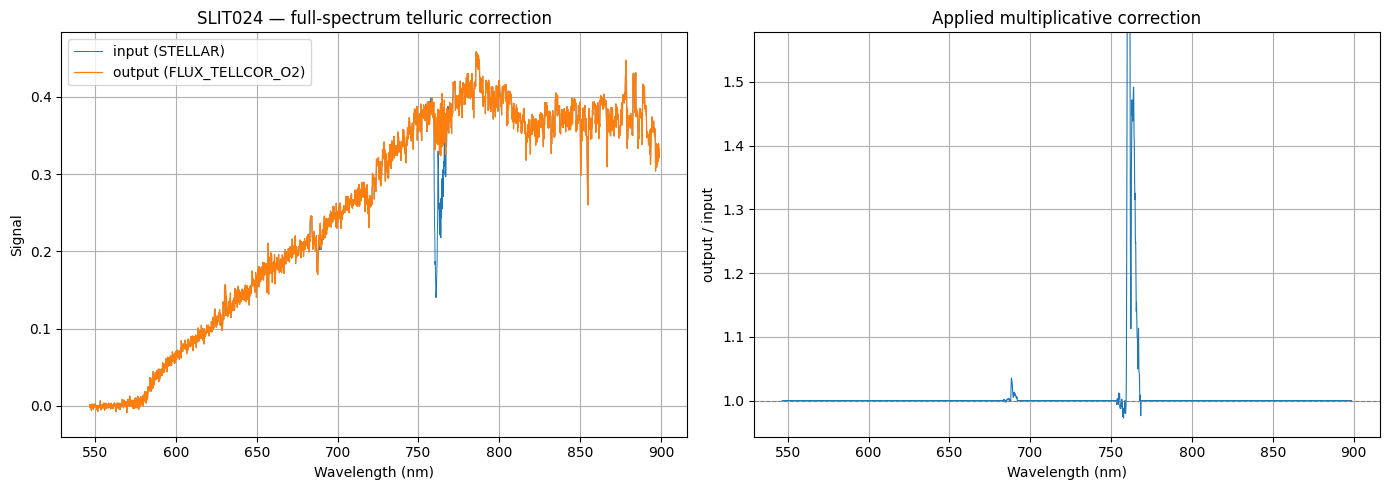

In [32]:
if OUTFILE.exists() and flux_in is not None and flux_out is not None:
    fig = plt.figure(figsize=(14, 5))

    ax = fig.add_subplot(121)
    ax.plot(lam_in, flux_in, lw=0.7, label=f"input ({flux_in_col})")
    ax.plot(lam_in, flux_out, lw=0.9, label=f"output ({flux_out_col})")
    ax.set_title(f"{SLIT} — full-spectrum telluric correction")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("Signal")
    ax.set_ylim(*finite_ylim(flux_in, flux_out))
    ax.legend()

    ax = fig.add_subplot(122)
    ratio = np.full_like(flux_out, np.nan, dtype=float)
    m = np.isfinite(flux_in) & np.isfinite(flux_out) & (np.abs(flux_in) > 0)
    ratio[m] = flux_out[m] / flux_in[m]
    ax.plot(lam_in, ratio, lw=0.8)
    ax.axhline(1.0, lw=0.8, ls="--", color="0.5")
    ax.set_title("Applied multiplicative correction")
    ax.set_xlabel("Wavelength (nm)")
    ax.set_ylabel("output / input")
    ax.set_ylim(*finite_ylim(ratio))

    plt.tight_layout()
    plt.show()

## Zoom on telluric bands

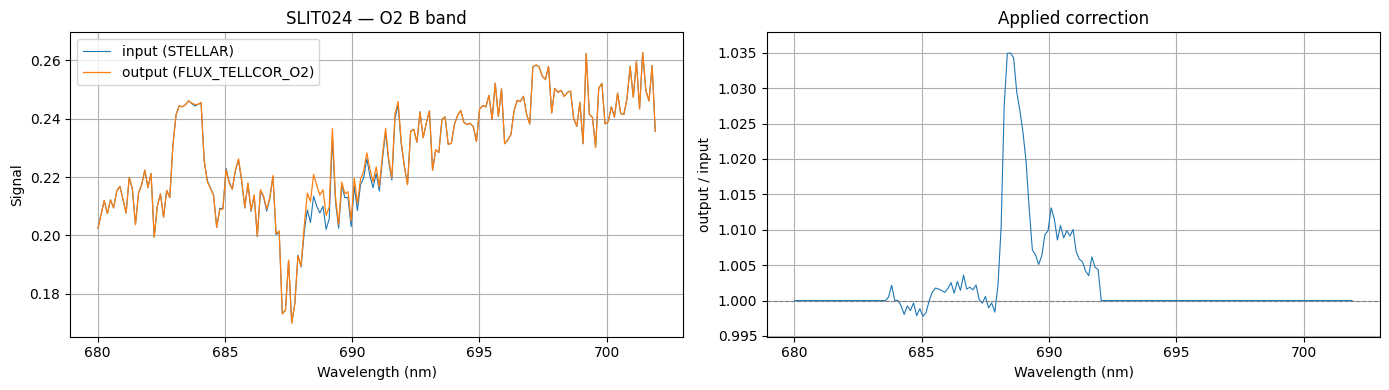

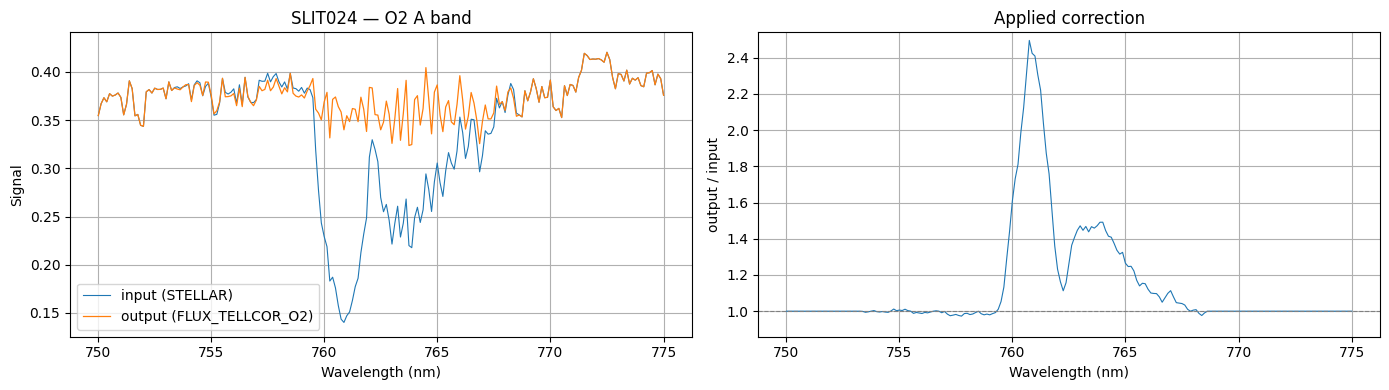

In [33]:
if OUTFILE.exists() and flux_in is not None and flux_out is not None:
    for lo, hi, title in [(680, 702, "O2 B band"), (750, 775, "O2 A band")]:
        m = np.isfinite(lam_in) & (lam_in >= lo) & (lam_in <= hi)

        fig = plt.figure(figsize=(14, 4))

        ax = fig.add_subplot(121)
        ax.plot(lam_in[m], flux_in[m], lw=0.8, label=f"input ({flux_in_col})")
        ax.plot(lam_in[m], flux_out[m], lw=0.9, label=f"output ({flux_out_col})")
        ax.set_title(f"{SLIT} — {title}")
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("Signal")
        ax.set_ylim(*finite_ylim(flux_in[m], flux_out[m]))
        ax.legend()

        ax = fig.add_subplot(122)
        ratio = np.full_like(flux_out[m], np.nan, dtype=float)
        mm = np.isfinite(flux_in[m]) & np.isfinite(flux_out[m]) & (np.abs(flux_in[m]) > 0)
        ratio[mm] = flux_out[m][mm] / flux_in[m][mm]
        ax.plot(lam_in[m], ratio, lw=0.8)
        ax.axhline(1.0, lw=0.8, ls="--", color="0.5")
        ax.set_title("Applied correction")
        ax.set_xlabel("Wavelength (nm)")
        ax.set_ylabel("output / input")
        ax.set_ylim(*finite_ylim(ratio))

        plt.tight_layout()
        plt.show()

[CMD] python '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/samos-pipeline/qc/step10/qc_step10_final_mosaic.py' --infile '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric_official/extract1d_optimal_ridge_all_wav_ohclean_tellcorr.fits' --outdir '/Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric_official/qc_step10' --png-name all_stellar_tellcorr_wavelength_montage.png --column FLUX_TELLCOR_O2
--- STDOUT ---
Wrote: /Users/robberto/Library/CloudStorage/Box-Box/My Documents - Massimo Robberto/@Massimo/_Science/2. Projects_HW/2017.SAMOS/_Run8_Science_2026_01/SAMI/Dolidze25/reduced/10_telluric_official/qc_step10/all_stellar_tellcorr_wavelength_montage.png
Wrote: /Us

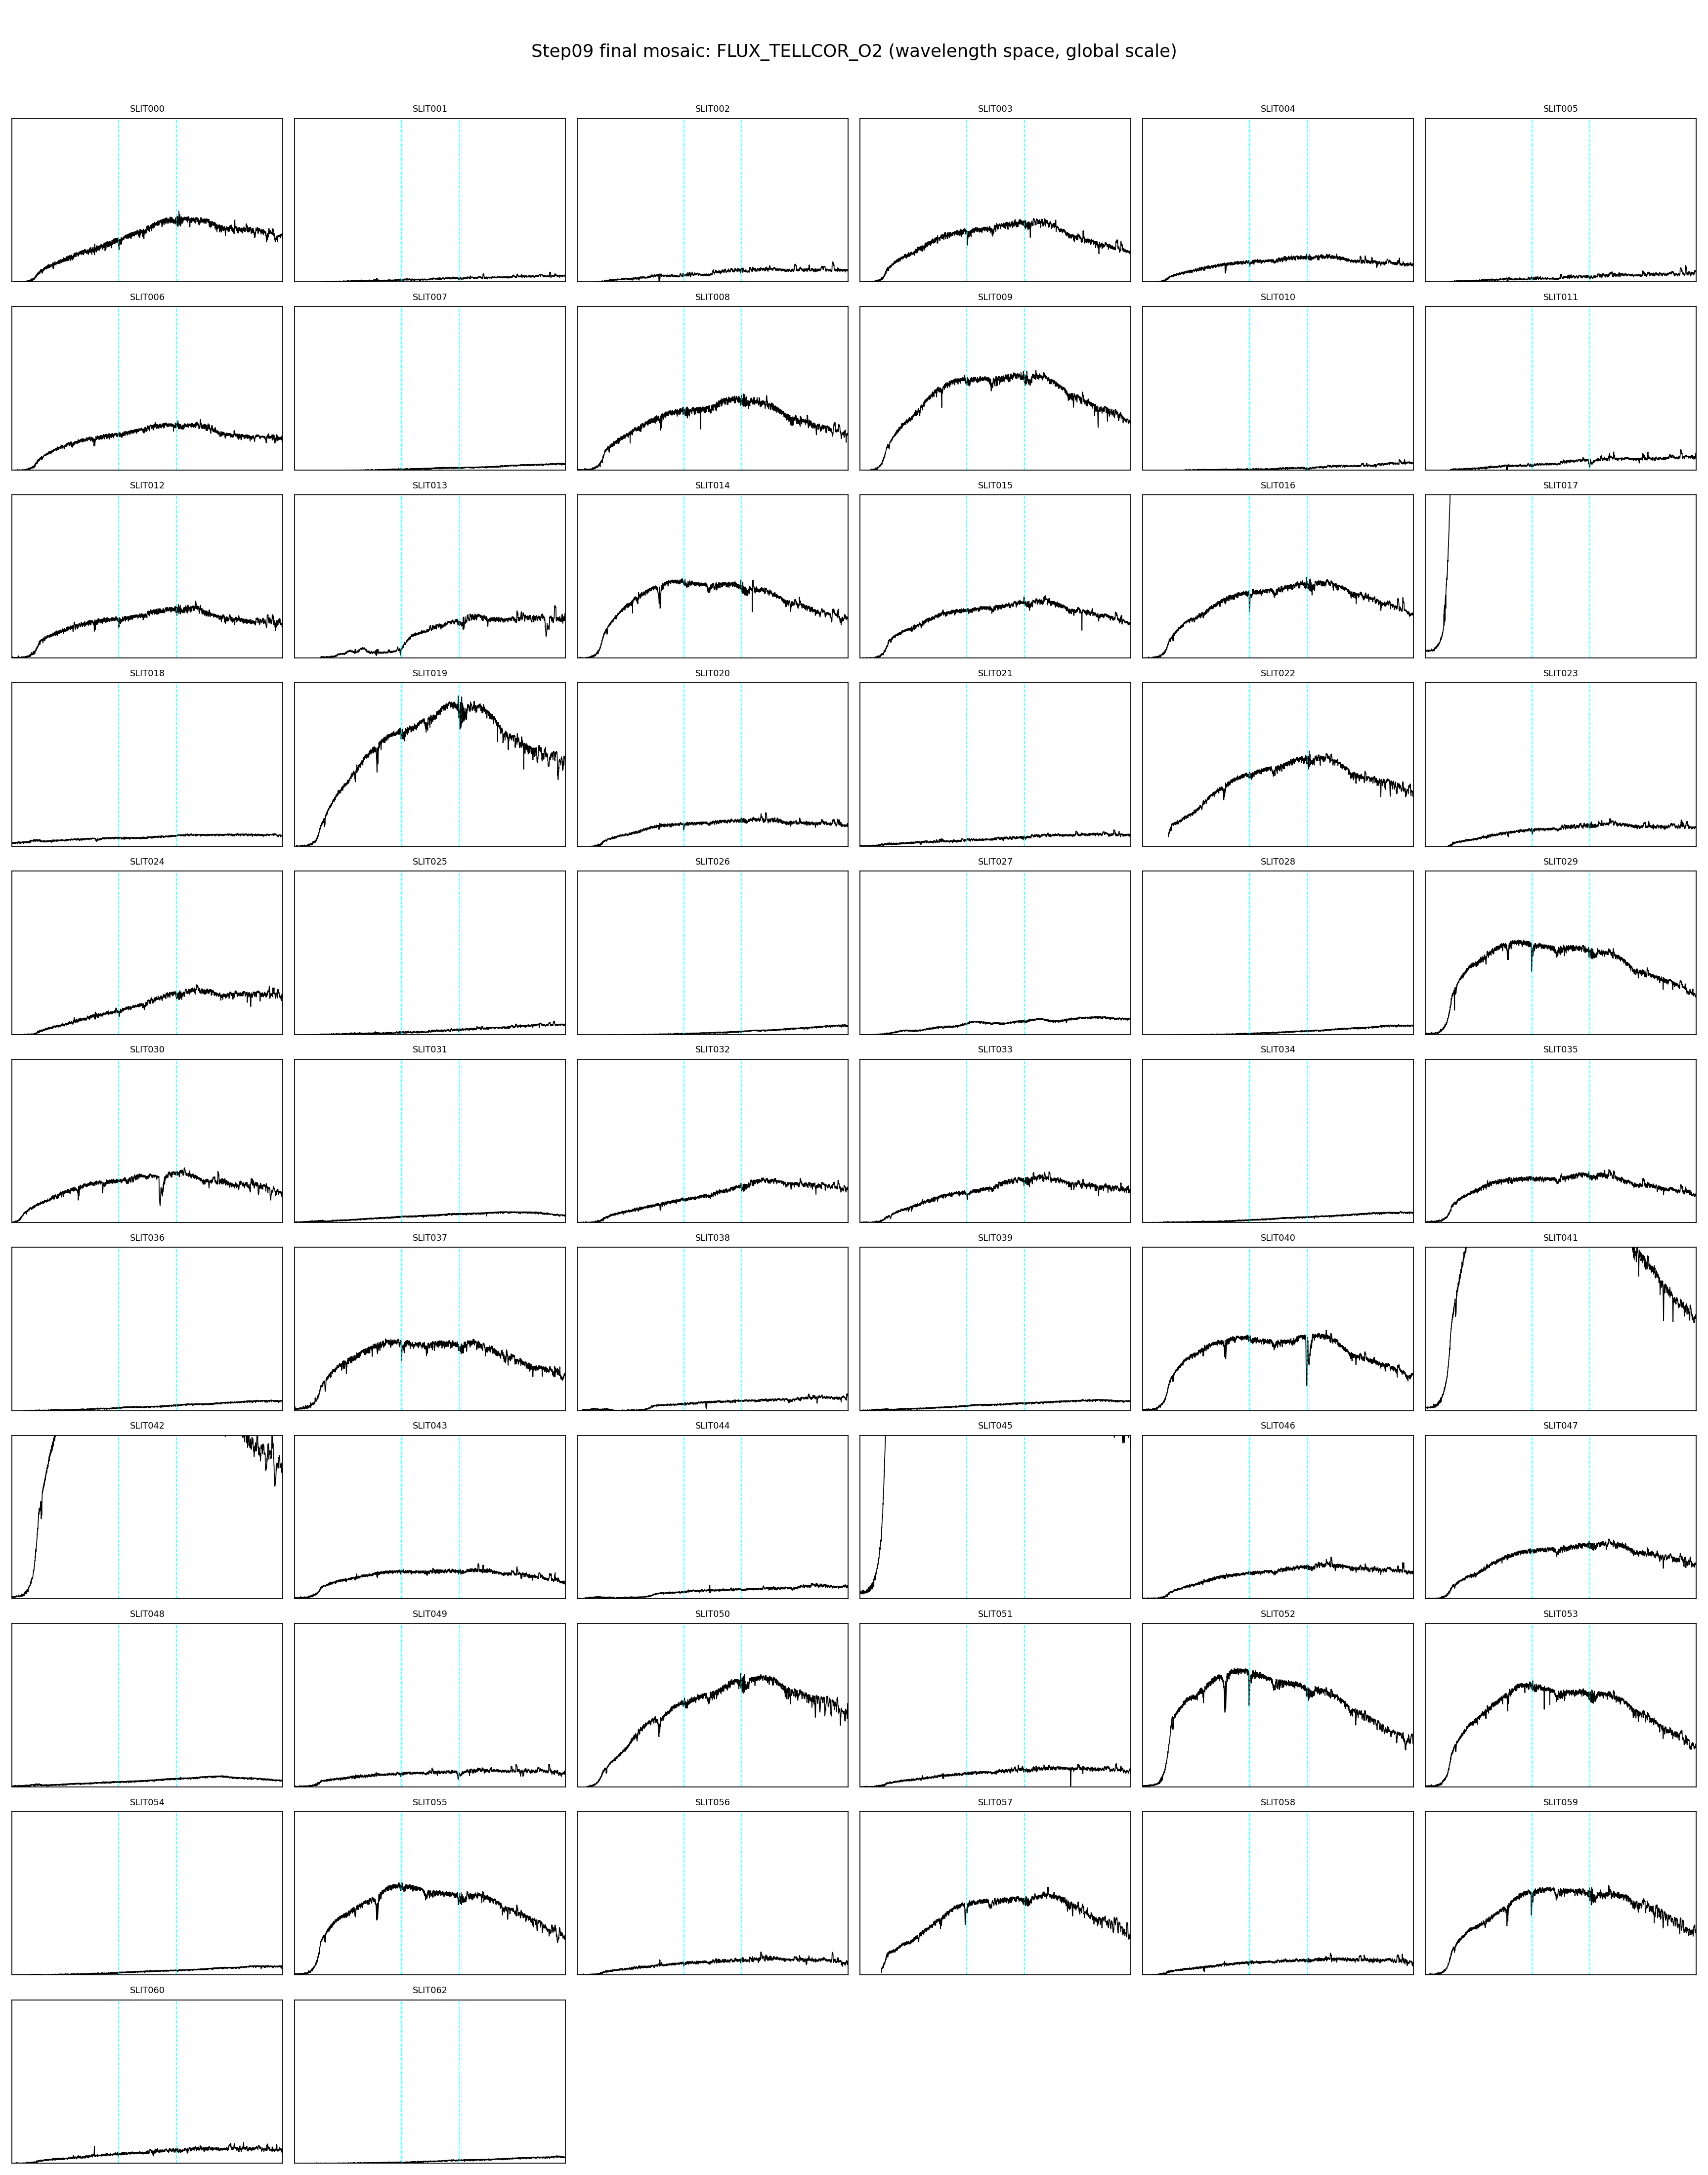

In [47]:
if RUN_QC_MOSAIC:
    run_cmd([
        PYTHON,
        QC_MOSAIC,
        "--infile", OUTFILE,
        "--outdir", QC_MOSAIC_DIR,
        "--png-name", QC_MOSAIC_PNG.name,
        "--column", "FLUX_TELLCOR_O2",   # fallback handled inside script
    ])

    from IPython.display import Image, display
    display(Image(filename=QC_MOSAIC_PNG))

else:
    print("RUN_QC_MOSAIC = False  -> skipped")

## Step10 status note

At the moment, the uploaded QC files are **not yet the right official QC layer** for the current Step10 semantics.

The uploaded files `qc_step10_oh.py`, `qc_step10_oh_b.py`, and `QC10c_OH_shift_summary_from_SKY.py`
are tied to the **old OH-shift workflow**, not the current telluric stage.
So the notebook does not call them.

## Handoff

Once Step10 is validated, the corrected file to pass downstream is:

`extract1d_optimal_ridge_all_wav_ohclean_tellcorr.fits`

Primary new science columns include:

- `FLUX_TELLCOR_O2`
- `VAR_TELLCOR_O2` (if present)

Relevant telluric fit metadata live in the slit headers, e.g.:

- `TELL_OK`
- `TELL_OKA`
- `TELL_OKB`
- `TELL_SHA`
- `TELL_SHB`
- `TELL_AA`
- `TELL_AB`
- `TELLBAND`